# BERT Fine-Tuning — Domain-Adaptive Sentiment Analysis

Separated from `main.ipynb`. This notebook reads `general_clean.csv` and `domain_clean.csv`
directly (cleaned in `main.ipynb`), so it runs independently.

**Run order:** Setup -> LR sweep -> S1 -> S2 -> S3 -> Summary -> Extensions.
After each strategy, free the model with `del trainer; cleanup()`.

## 1. Setup

In [34]:
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback, set_seed)
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import Dataset
import datasets

import sys
assert "anaconda3" in sys.executable, f"WRONG KERNEL: {sys.executable}"
print("kernel:", sys.executable)
print("MPS:", torch.backends.mps.is_available())

kernel: /opt/anaconda3/bin/python
MPS: True


In [35]:
seed       = 42
model_name = "cardiffnlp/twitter-roberta-base"
max_len    = 64

tokenizer = AutoTokenizer.from_pretrained(model_name)

## 2. Data and label mapping (28 -> 12 classes)

In [36]:
label_map = {
    "realization": "ambiguous",
    "amusement":      "amusement",
    "anger":          "anger",      "annoyance":    "anger",      "disapproval": "anger",
    "nervousness":    "anxiety",
    "admiration":     "belief",     "approval":     "belief",     "caring":      "belief",
    "pride":          "belief",     "gratitude":    "belief",     "love":        "belief",
    "confusion":      "confusion",  "curiosity":    "confusion",
    "sadness":        "depression", "grief":        "depression", "remorse":     "depression",
    "disappointment": "depression", "embarrassment":"depression",
    "disgust":        "disgust",
    "excitement":     "excitement", "joy":          "excitement",
    "optimism":       "optimism",   "relief":       "optimism",   "desire":      "optimism",
    "fear":           "panic",
    "surprise":       "surprise",
    # "neutral" is deliberately unmapped -> dropped (supported by ablation experiment)
}

general = pd.read_csv("general_clean.csv")
domain  = pd.read_csv("domain_clean.csv").rename(columns={"emo_label": "label"})

general["label"] = general["label"].map(label_map)
general = general.dropna(subset=["label"]).reset_index(drop=True)

assert set(general["label"]) == set(domain["label"]), "Label spaces do not match!"
print(f"general: {len(general)} rows | domain: {len(domain)} rows | {general['label'].nunique()} classes")

general: 38042 rows | domain: 10000 rows | 12 classes


In [37]:
# Train / validation / test split
general_train, general_val = train_test_split(general, test_size=.2, stratify=general["label"], random_state=seed)
domain_train, domain_rest  = train_test_split(domain,  test_size=.3, stratify=domain["label"],  random_state=seed)
domain_val, domain_test    = train_test_split(domain_rest, test_size=.5, stratify=domain_rest["label"], random_state=seed)

print(f"general {len(general_train)}/{len(general_val)} | domain {len(domain_train)}/{len(domain_val)}/{len(domain_test)}")

general 30433/7609 | domain 7000/1500/1500


In [38]:
# Label encoding - fixed order shared by BOTH datasets
labels = sorted(domain["label"].unique())
label2id = {l: i for i, l in enumerate(labels)}
id2label = {i: l for l, i in label2id.items()}

def to_dataset(df):
    ds = Dataset.from_pandas(df[["text", "label"]].reset_index(drop=True))
    return ds.map(lambda b: {**tokenizer(b["text"], truncation=True, max_length=max_len), "labels": [label2id[l] for l in b["label"]]}, batched=True, remove_columns=["text", "label"])

datasets.disable_caching()          # keep in RAM, no Arrow cache files on disk

## 3. Class weights and architecture

In [ ]:
# cw_power: 0   = no weighting (highest accuracy)
#           0.5 = balanced trade-off (recommended)
#           1.0 = full 'balanced' (highest macro-F1, lowest accuracy)
def make_class_weights(train_df, power=0.5):
    if power == 0:
        return None
    y = [label2id[l] for l in train_df["label"]]
    w = compute_class_weight("balanced", classes=np.arange(len(labels)), y=y)
    return torch.tensor(np.power(w, power), dtype=torch.float)


class WeightedTrainer(Trainer):
    """Trainer with weighted cross-entropy (the stock Trainer has no class-weight support).

    NOTE: overriding compute_loss bypasses TrainingArguments.label_smoothing_factor,
    so label smoothing is applied explicitly here.
    """
    def __init__(self, class_weights=None, **kw):
        super().__init__(**kw)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        y   = inputs.pop("labels")
        out = model(**inputs)
        w   = self.class_weights.to(out.logits.device) if self.class_weights is not None else None
        loss = nn.functional.cross_entropy(
            out.logits, y, weight=w,
            label_smoothing=self.args.label_smoothing_factor)     # honour the TrainingArguments setting
        return (loss, out) if return_outputs else loss

In [42]:
class MeanPoolClassifier(nn.Module):
    """Mean of ALL token vectors instead of using only [CLS]."""
    def __init__(self, base_model, num_labels, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(base_model)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(self.bert.config.hidden_size, num_labels)
        self.num_labels = num_labels

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kw):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        m   = attention_mask.unsqueeze(-1).float()
        pooled = (out * m).sum(1) / m.sum(1).clamp(min=1e-9)      # ignore padding
        logits = self.fc(self.drop(pooled))
        loss = nn.functional.cross_entropy(logits, labels) if labels is not None else None
        return SequenceClassifierOutput(loss=loss, logits=logits)

## 4. Train / evaluate / plot helpers

In [ ]:
def compute_metrics(p):
    pred = p.predictions.argmax(-1)
    return {"macro_f1": f1_score(p.label_ids, pred, average="macro", zero_division=0),
            "accuracy":  accuracy_score(p.label_ids, pred)}


def finetune(name, train_df, val_df, init_from=model_name, pooling="cls", epochs=3, lr=2e-5, batch=32, patience=2, cw_power=0.5, run_seed=None):
    s = seed if run_seed is None else run_seed
    set_seed(s)

    model = (AutoModelForSequenceClassification.from_pretrained( init_from, num_labels=len(labels), id2label=id2label, label2id=label2id)
             if pooling == "cls" else MeanPoolClassifier(init_from, num_labels=len(labels)))

    n_steps = int(np.ceil(len(train_df) / batch)) * epochs
    args = TrainingArguments(
        output_dir=f"checkpoints/{name}", seed=s,
        num_train_epochs=epochs, learning_rate=lr, warmup_steps=int(0.1 * n_steps),
        weight_decay=0.01,                          # L2 regularisation (was missing -> defaulted to 0)
        label_smoothing_factor=0.1,                 # curbs over-confidence on ambiguous labels
        lr_scheduler_type="cosine",                 # smoother decay than linear
        per_device_train_batch_size=batch, per_device_eval_batch_size=64,
        eval_strategy="epoch", save_strategy="epoch", save_total_limit=1,
        save_only_model=True,                       # skip optimizer.pt (~1GB) every epoch
        load_best_model_at_end=True, metric_for_best_model="macro_f1", greater_is_better=True,
        logging_strategy="steps", logging_steps=50,
        report_to="none", dataloader_pin_memory=False)

    trainer = WeightedTrainer(
        class_weights=make_class_weights(train_df, cw_power),
        model=model, args=args, processing_class=tokenizer,
        train_dataset=to_dataset(train_df), eval_dataset=to_dataset(val_df),
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=patience)])
    trainer.train()
    return trainer

In [44]:
def evaluate_bert(trainer, test_df, name, save=True, val_df=None):
    out  = trainer.predict(to_dataset(test_df))
    pred = [id2label[i] for i in out.predictions.argmax(-1)]
    y    = test_df["label"].tolist()
    print(f"{name} | macro-F1 = {f1_score(y, pred, average='macro', zero_division=0):.4f} "
          f"| accuracy = {accuracy_score(y, pred):.4f}\n")
    print(classification_report(y, pred, zero_division=0))
    if save:
        np.save(f"results/logits_{name}.npy", out.predictions)       # test logits -> ensembling
        pd.DataFrame({"true": y, "pred": pred}).to_csv(f"results/pred_{name}.csv", index=False)
        if val_df is not None:                                        # val logits -> prior tuning
            np.save(f"results/vallogits_{name}.npy", trainer.predict(to_dataset(val_df)).predictions)
    return pred


def plot_training(trainer, name):
    log  = pd.DataFrame(trainer.state.log_history)
    tr   = log[log["loss"].notna()]
    ev   = log[log["eval_loss"].notna()]
    best = ev.loc[ev["eval_macro_f1"].idxmax()]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    ax1.plot(tr["step"], tr["loss"], color="steelblue", lw=1, alpha=.6,
             label=f"train loss (every {trainer.args.logging_steps} steps)")
    ax1.plot(ev["step"], ev["eval_loss"], "o-", color="tomato", lw=2, label="val loss (every epoch)")
    ax1.set(xlabel="step", ylabel="loss", title=f"Loss — {name}")
    ax1.legend(); ax1.grid(alpha=.3)

    ax2.plot(ev["epoch"], ev["eval_macro_f1"], "o-", color="seagreen", lw=2)
    ax2.axvline(best["epoch"], color="gray", ls="--", lw=1)
    ax2.annotate(f"best {best['eval_macro_f1']:.3f} @ epoch {best['epoch']:.0f}",
                 (best["epoch"], best["eval_macro_f1"]), textcoords="offset points", xytext=(8, -20), fontsize=9)
    ax2.set(xlabel="epoch", ylabel="val macro-F1", title=f"Validation macro-F1 — {name}", xticks=ev["epoch"])
    ax2.grid(alpha=.3)
    plt.tight_layout(); plt.show()

    print(f"Stopped at epoch {ev['epoch'].max():.0f}/{trainer.args.num_train_epochs} "
          f"| best epoch {best['epoch']:.0f} (val macro-F1 {best['eval_macro_f1']:.4f})")


def cleanup():
    """Call AFTER `del`-ing the trainer in the notebook."""
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    print("RAM released")

In [ ]:
import os
os.makedirs("results", exist_ok=True)

for n in ["seed","model_name","tokenizer","labels","label2id","id2label",
          "general_train","general_val","domain_train","domain_val","domain_test",
          "to_dataset","compute_metrics","finetune","evaluate_bert","plot_training","cleanup"]:
    assert n in globals(), f"MISSING: {n} — re-run the definition cells"
print("All prerequisites met — ready to train.")

import subprocess
sw = subprocess.run(["sysctl","-n","vm.swapusage"], capture_output=True, text=True).stdout
used = float(sw.split("used =")[1].split("M")[0])
print(f"swap used: {used:.0f} MB", "-> OK" if used < 1500 else "-> HIGH, restart the machine first")

## 5. Learning-rate selection

Measured on `domain_val`, **never** on `domain_test`. Once chosen, keep it fixed across all three strategies.

In [24]:
lr_results = []
for lr in [1e-5, 2e-5, 3e-5]:
    t = finetune(f"lr{lr}", domain_train, domain_val, epochs=3, lr=lr, cw_power=0.5)
    m = t.evaluate()
    lr_results.append({"lr": lr, "val_macro_f1": m["eval_macro_f1"], "val_accuracy": m["eval_accuracy"]})
    del t; cleanup()

print(pd.DataFrame(lr_results).round(4).to_string(index=False))
BEST_LR = max(lr_results, key=lambda r: r["val_macro_f1"])["lr"]
print("Selected lr =", BEST_LR)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,2.203770,2.038632,0.253279,0.332000
2,1.927496,1.883903,0.296389,0.344667
3,1.838096,1.847427,0.318482,0.374667


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
1.493667,1.742495,3,0.390453,0.400667


RAM released
 lr  val_macro_f1  val_accuracy
0.0        0.3185        0.3747
0.0        0.3692        0.3880
0.0        0.3905        0.4007
Selected lr = 3e-05


### Skip the sweep

The sweep already ran: `1e-5 -> 0.3185`, `2e-5 -> 0.3692`, **`3e-5 -> 0.3905`** (val macro-F1).
After a kernel restart, set the value directly instead of re-running the 20-minute sweep.

In [46]:
BEST_LR = 3e-5
print("BEST_LR =", BEST_LR)

BEST_LR = 3e-05


## 6. Strategy 1 — Domain only  (= Model B)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,2.031124,1.924793,0.273134,0.322667
2,1.762583,1.755005,0.358890,0.368000
3,1.463882,1.776899,0.370831,0.379333
4,1.195596,1.791544,0.402023,0.412000
5,1.038819,1.850388,0.385939,0.388667
6,0.915670,1.873950,0.389122,0.394667


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

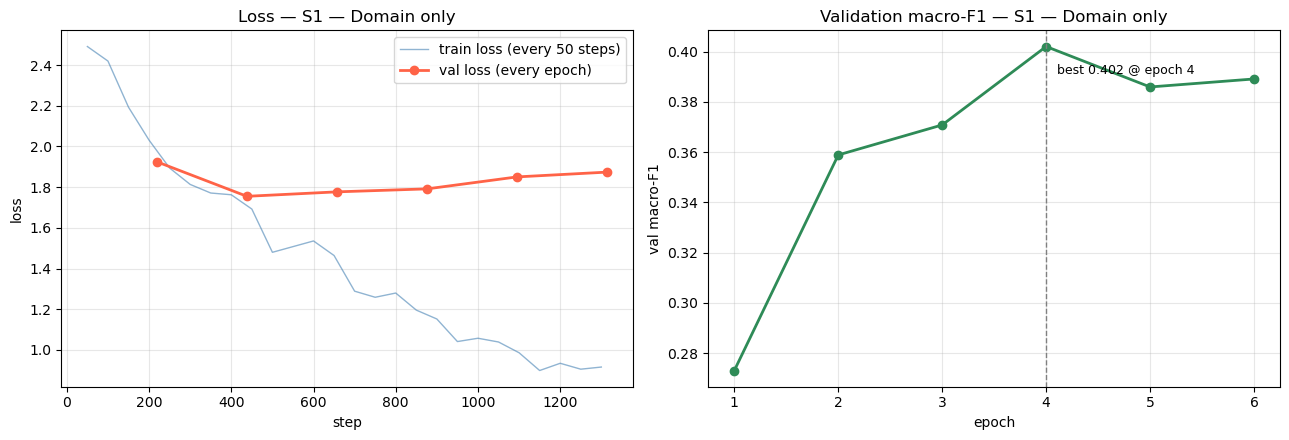

Stopped at epoch 6/6 | best epoch 4 (val macro-F1 0.4020)


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

S1 | macro-F1 = 0.3645 | accuracy = 0.3893

              precision    recall  f1-score   support

   ambiguous       0.26      0.12      0.17       130
   amusement       0.35      0.32      0.33       122
       anger       0.36      0.34      0.35        58
     anxiety       0.37      0.45      0.41       205
      belief       0.31      0.44      0.37       136
   confusion       0.54      0.55      0.55        92
  depression       0.23      0.29      0.26        31
     disgust       0.42      0.44      0.43       192
  excitement       0.48      0.49      0.48       208
    optimism       0.44      0.33      0.38       244
       panic       0.30      0.35      0.32        46
    surprise       0.30      0.36      0.33        36

    accuracy                           0.39      1500
   macro avg       0.36      0.37      0.36      1500
weighted avg       0.39      0.39      0.38      1500

RAM released


In [25]:
trainer_s1 = finetune("S1", domain_train, domain_val, epochs=6, lr=BEST_LR, cw_power=0.5)
plot_training(trainer_s1, "S1 — Domain only")
pred_s1 = evaluate_bert(trainer_s1, domain_test, "S1")
del trainer_s1; cleanup()

## 7. Strategy 2 — Sequential transfer

Stage 1 on GoEmotions (= **Model A**), stage 2 continues fine-tuning on StockEmotions.
Evaluate stage 1 **before** running stage 2.

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

Map:   0%|          | 0/30433 [00:00<?, ? examples/s]

Map:   0%|          | 0/7609 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,1.026769,1.059157,0.610750,0.688921
2,0.869074,0.996645,0.623511,0.688790
3,0.670043,1.022382,0.626611,0.692864


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

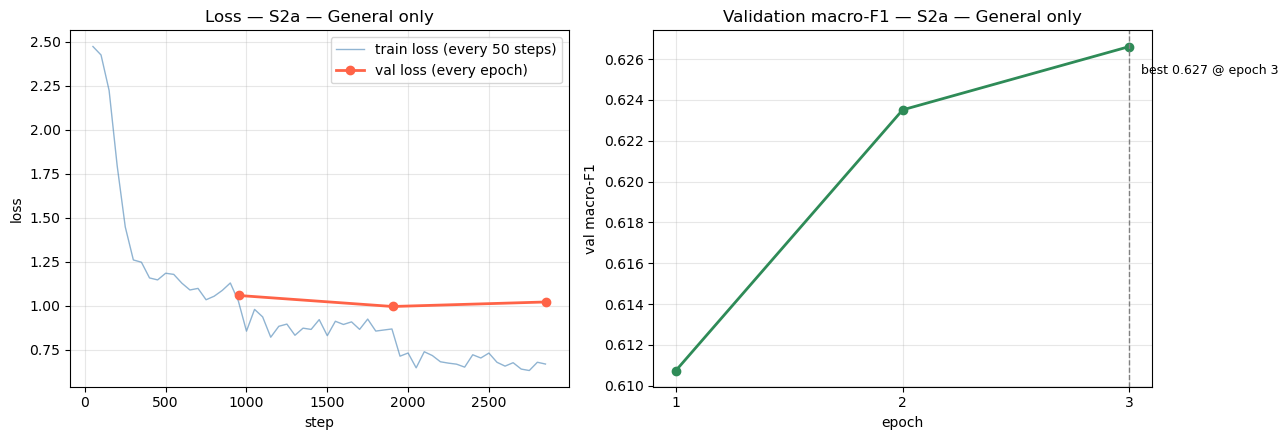

Stopped at epoch 3/3 | best epoch 3 (val macro-F1 0.6266)


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

S2a | macro-F1 = 0.1387 | accuracy = 0.1680

              precision    recall  f1-score   support

   ambiguous       0.09      0.09      0.09       130
   amusement       0.09      0.08      0.09       122
       anger       0.10      0.31      0.15        58
     anxiety       0.33      0.01      0.02       205
      belief       0.16      0.29      0.21       136
   confusion       0.19      0.37      0.25        92
  depression       0.08      0.26      0.12        31
     disgust       0.17      0.01      0.01       192
  excitement       0.23      0.24      0.24       208
    optimism       0.25      0.29      0.27       244
       panic       0.12      0.04      0.06        46
    surprise       0.15      0.17      0.16        36

    accuracy                           0.17      1500
   macro avg       0.16      0.18      0.14      1500
weighted avg       0.20      0.17      0.14      1500



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

RAM released


In [26]:
trainer_s2a = finetune("S2a", general_train, general_val, epochs=3, lr=BEST_LR, cw_power=0.5)
plot_training(trainer_s2a, "S2a — General only")
pred_A = evaluate_bert(trainer_s2a, domain_test, "S2a")      # = Model A
trainer_s2a.save_model("checkpoints/S2a/best")
del trainer_s2a; cleanup()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,1.911724,1.878250,0.322824,0.348000
2,1.697096,1.771148,0.368102,0.368667
3,1.444456,1.785714,0.375646,0.380667
4,1.142756,1.850924,0.380221,0.377333
5,0.983136,1.922765,0.379948,0.384667
6,0.854135,1.946862,0.383581,0.386667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

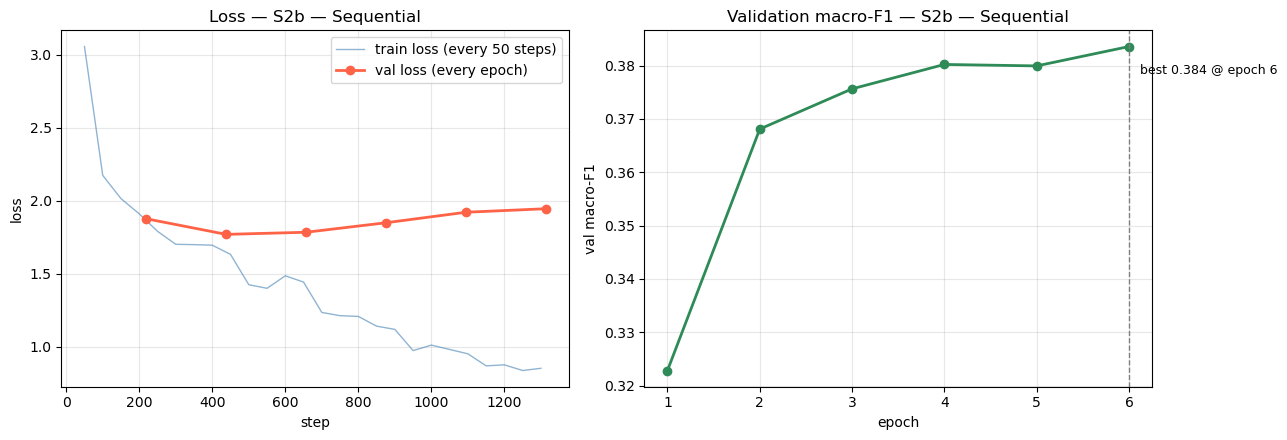

Stopped at epoch 6/6 | best epoch 6 (val macro-F1 0.3836)


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

S2 | macro-F1 = 0.3528 | accuracy = 0.3753

              precision    recall  f1-score   support

   ambiguous       0.20      0.14      0.16       130
   amusement       0.38      0.39      0.38       122
       anger       0.34      0.45      0.39        58
     anxiety       0.42      0.39      0.40       205
      belief       0.33      0.42      0.37       136
   confusion       0.55      0.50      0.53        92
  depression       0.20      0.19      0.20        31
     disgust       0.40      0.40      0.40       192
  excitement       0.41      0.47      0.44       208
    optimism       0.41      0.34      0.37       244
       panic       0.29      0.33      0.31        46
    surprise       0.25      0.36      0.30        36

    accuracy                           0.38      1500
   macro avg       0.35      0.36      0.35      1500
weighted avg       0.38      0.38      0.37      1500

RAM released


In [27]:
trainer_s2b = finetune("S2b", domain_train, domain_val,
                       init_from="checkpoints/S2a/best", epochs=6, lr=BEST_LR, cw_power=0.5)
plot_training(trainer_s2b, "S2b — Sequential")
pred_s2 = evaluate_bert(trainer_s2b, domain_test, "S2")
del trainer_s2b; cleanup()

## 8. Strategy 3 — Mixed  (= Model C)

mixed: 37433 | domain share 18.7%


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

Map:   0%|          | 0/37433 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,1.222196,1.868217,0.254410,0.348667
2,1.034570,1.727929,0.328934,0.387333
3,0.865159,1.744906,0.345375,0.394000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

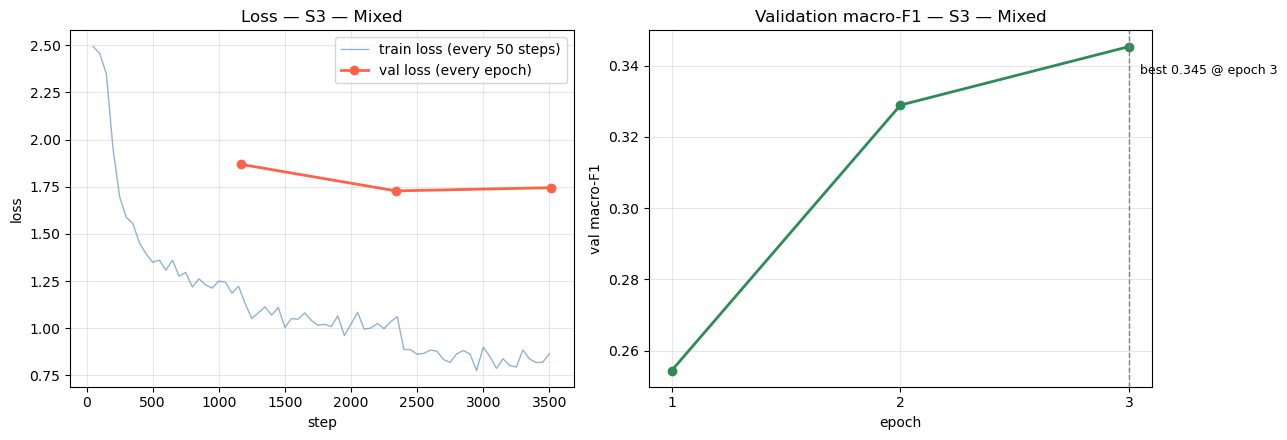

Stopped at epoch 3/3 | best epoch 3 (val macro-F1 0.3454)


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

S3 | macro-F1 = 0.3564 | accuracy = 0.4047

              precision    recall  f1-score   support

   ambiguous       0.24      0.13      0.17       130
   amusement       0.38      0.30      0.33       122
       anger       0.56      0.16      0.24        58
     anxiety       0.37      0.61      0.46       205
      belief       0.36      0.10      0.15       136
   confusion       0.73      0.43      0.54        92
  depression       0.38      0.26      0.31        31
     disgust       0.39      0.57      0.46       192
  excitement       0.48      0.52      0.50       208
    optimism       0.42      0.45      0.43       244
       panic       0.28      0.37      0.32        46
    surprise       0.33      0.36      0.35        36

    accuracy                           0.40      1500
   macro avg       0.41      0.35      0.36      1500
weighted avg       0.41      0.40      0.39      1500

RAM released


In [28]:
mixed_train = pd.concat([general_train[["text","label"]],
                         domain_train[["text","label"]]], ignore_index=True)
print("mixed:", len(mixed_train), "| domain share", f"{len(domain_train)/len(mixed_train)*100:.1f}%")

trainer_s3 = finetune("S3", mixed_train, domain_val, epochs=3, lr=BEST_LR, cw_power=0.5)
plot_training(trainer_s3, "S3 — Mixed")
pred_s3 = evaluate_bert(trainer_s3, domain_test, "S3")
del trainer_s3; cleanup()

## 9. Summary table + confusion matrix

In [29]:
y = domain_test["label"]
rows = [("A  — General only (S2a)",  len(general_train), pred_A),
        ("B  — Domain only (S1)",    len(domain_train),  pred_s1),
        ("C  — Mixed (S3)",          len(mixed_train),   pred_s3),
        ("S2 — Sequential transfer", len(domain_train),  pred_s2)]

summary = pd.DataFrame([{"strategy": n, "train_size": sz,
                         "macro_f1": f1_score(y, p, average="macro", zero_division=0),
                         "accuracy": accuracy_score(y, p)} for n, sz, p in rows]).round(4)
print(summary.to_string(index=False))
summary.to_csv("results/summary_bert.csv", index=False)

                strategy  train_size  macro_f1  accuracy
 A  — General only (S2a)       30433    0.1387    0.1680
   B  — Domain only (S1)        7000    0.3645    0.3893
         C  — Mixed (S3)       37433    0.3564    0.4047
S2 — Sequential transfer        7000    0.3528    0.3753


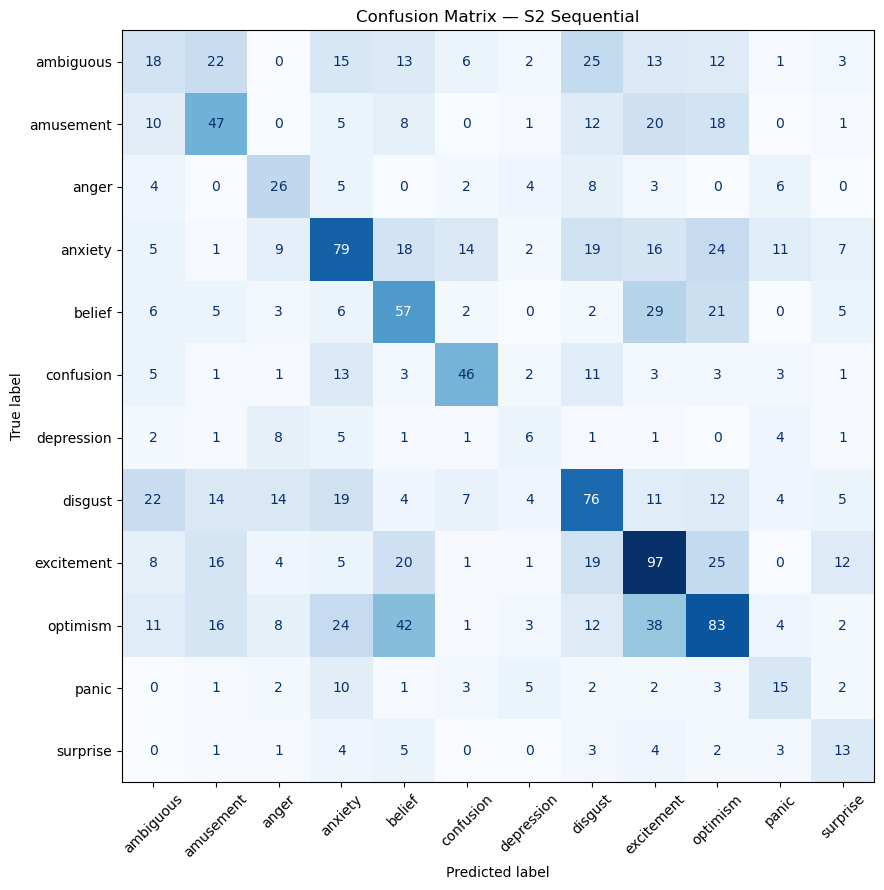

In [30]:
fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay.from_predictions(y, pred_s2, xticks_rotation=45, cmap="Blues", ax=ax, colorbar=False)
ax.set_title("Confusion Matrix — S2 Sequential")
plt.tight_layout(); plt.show()

## 10. Extensions

Only run these after the three main strategies are complete.

In [31]:
# Seed ensemble: average logits across 3 seeds
for s in [1, 2]:
    t = finetune(f"S1_seed{s}", domain_train, domain_val, epochs=6, lr=BEST_LR, cw_power=0.5, run_seed=s)
    evaluate_bert(t, domain_test, f"S1_seed{s}")
    del t; cleanup()

y = domain_test["label"]
logits   = np.mean([np.load(f"results/logits_{n}.npy") for n in ["S1", "S1_seed1", "S1_seed2"]], axis=0)
pred_ens = [id2label[i] for i in logits.argmax(-1)]
print(f"ENSEMBLE 3 seed | macro-F1 = {f1_score(y, pred_ens, average='macro', zero_division=0):.4f} "f"| accuracy = {accuracy_score(y, pred_ens):.4f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,2.010204,1.889305,0.307790,0.368667
2,1.687485,1.739063,0.384884,0.402667
3,1.434412,1.735087,0.396821,0.400000
4,1.191168,1.784991,0.401278,0.406667
5,0.984605,1.867929,0.400880,0.406000
6,0.838235,1.904357,0.402877,0.408000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

S1_seed2 | macro-F1 = 0.3553 | accuracy = 0.3833

              precision    recall  f1-score   support

   ambiguous       0.23      0.21      0.22       130
   amusement       0.36      0.17      0.23       122
       anger       0.28      0.45      0.35        58
     anxiety       0.39      0.43      0.41       205
      belief       0.39      0.38      0.38       136
   confusion       0.52      0.54      0.53        92
  depression       0.25      0.26      0.25        31
     disgust       0.40      0.44      0.42       192
  excitement       0.50      0.51      0.50       208
    optimism       0.43      0.32      0.37       244
       panic       0.23      0.41      0.30        46
    surprise       0.23      0.39      0.29        36

    accuracy                           0.38      1500
   macro avg       0.35      0.38      0.36      1500
weighted avg       0.39      0.38      0.38      1500

RAM released
ENSEMBLE 3 seed | macro-F1 = 0.3775 | accuracy = 0.4047


In [32]:
# Mean pooling instead of [CLS]
t = finetune("S1_mean", domain_train, domain_val, pooling="mean", epochs=6, lr=BEST_LR, cw_power=0.5)
pred_mean = evaluate_bert(t, domain_test, "S1_mean")
del t; cleanup()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,1.975104,1.861721,0.325667,0.366667
2,1.689796,1.720862,0.385173,0.393333
3,1.349424,1.732802,0.377912,0.389333
4,1.050669,1.828609,0.385025,0.391333


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

S1_mean | macro-F1 = 0.3661 | accuracy = 0.3813

              precision    recall  f1-score   support

   ambiguous       0.25      0.23      0.24       130
   amusement       0.31      0.39      0.34       122
       anger       0.36      0.31      0.33        58
     anxiety       0.44      0.35      0.39       205
      belief       0.34      0.37      0.35       136
   confusion       0.59      0.50      0.54        92
  depression       0.34      0.32      0.33        31
     disgust       0.44      0.35      0.39       192
  excitement       0.51      0.44      0.47       208
    optimism       0.41      0.41      0.41       244
       panic       0.23      0.43      0.30        46
    surprise       0.20      0.47      0.28        36

    accuracy                           0.38      1500
   macro avg       0.37      0.38      0.37      1500
weighted avg       0.40      0.38      0.39      1500

RAM released


## 11. Maximising performance (12-class task)

Each technique below is both an assignment deliverable **and** an extra member for the final
ensemble — more diverse training data means more diverse errors, which is what ensembling exploits.

Run order: longer S1 -> dataset weighting -> domain tags -> DAPT -> ensemble.

### 11.1 Longer training — S1 had not converged (best val at epoch 6 of 6)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

Map:   0%|          | 0/7000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,2.144330,1.960881,0.269218,0.321333
2,1.791897,1.740608,0.386510,0.393333
3,1.517750,1.764608,0.366090,0.378000
4,1.228218,1.816914,0.400601,0.406667
5,0.974637,1.954974,0.391014,0.404667
6,0.724283,2.124236,0.388073,0.399333
7,0.507686,2.321495,0.375388,0.386000


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

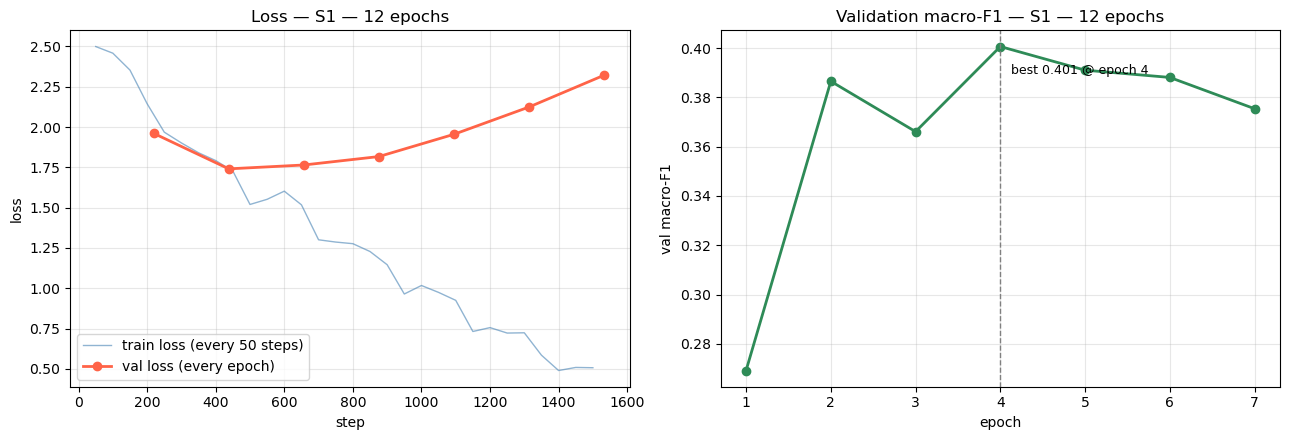

Stopped at epoch 7/12 | best epoch 4 (val macro-F1 0.4006)


Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

S1_long | macro-F1 = 0.3522 | accuracy = 0.3820

              precision    recall  f1-score   support

   ambiguous       0.22      0.19      0.20       130
   amusement       0.29      0.24      0.26       122
       anger       0.43      0.31      0.36        58
     anxiety       0.36      0.53      0.43       205
      belief       0.32      0.42      0.36       136
   confusion       0.44      0.58      0.50        92
  depression       0.21      0.29      0.25        31
     disgust       0.44      0.49      0.46       192
  excitement       0.51      0.40      0.45       208
    optimism       0.44      0.31      0.36       244
       panic       0.36      0.20      0.25        46
    surprise       0.35      0.31      0.33        36

    accuracy                           0.38      1500
   macro avg       0.37      0.35      0.35      1500
weighted avg       0.39      0.38      0.38      1500



Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

RAM released


In [48]:
trainer_s1l = finetune("S1_long", domain_train, domain_val,
                       epochs=12, patience=3, lr=BEST_LR, cw_power=0.5)
plot_training(trainer_s1l, "S1 — 12 epochs")
pred_s1_long = evaluate_bert(trainer_s1l, domain_test, "S1_long", val_df=domain_val)
del trainer_s1l; cleanup()

### 11.2 Transfer technique — dataset weighting

In the plain mixed set the target domain is only 18.7% of the data, so its signal is diluted.
Oversampling it 3x raises the share to ~41%.

In [ ]:
mixed_weighted = pd.concat([general_train[["text","label"]]] +
                           [domain_train[["text","label"]]] * 2, ignore_index=True)
print("mixed_weighted:", len(mixed_weighted),
      "| domain share:", f"{2*len(domain_train)/len(mixed_weighted)*100:.1f}%")

trainer_s3w = finetune("S3_weighted", mixed_weighted, domain_val,
                       epochs=3, lr=BEST_LR, cw_power=0.5)
plot_training(trainer_s3w, "S3 + dataset weighting")
pred_s3w = evaluate_bert(trainer_s3w, domain_test, "S3_weighted", val_df=domain_val)
del trainer_s3w; cleanup()

### 11.3 Transfer technique — domain tags

Prefixing each example with its origin lets the model condition on the domain instead of
being pulled towards the larger source distribution.

In [ ]:
gen_tag  = general_train[["text","label"]].assign(text=lambda d: "[GENERAL] " + d["text"])
dom_tag  = domain_train[["text","label"]].assign(text=lambda d: "[FINANCE] " + d["text"])
mixed_tag = pd.concat([gen_tag, dom_tag], ignore_index=True)

val_tag  = domain_val.assign(text="[FINANCE] "  + domain_val["text"])
test_tag = domain_test.assign(text="[FINANCE] " + domain_test["text"])

trainer_tag = finetune("S3_tagged", mixed_tag, val_tag, epochs=3, lr=BEST_LR, cw_power=0.5)
plot_training(trainer_tag, "S3 + domain tags")
pred_tag = evaluate_bert(trainer_tag, test_tag, "S3_tagged", val_df=val_tag)
del trainer_tag; cleanup()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream 

Map:   0%|          | 0/37433 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

KeyboardInterrupt: 

### 11.4 Transfer technique — Domain-Adaptive Pretraining (DAPT)

Continue masked-language-model pretraining on the 10,000 StockTwits texts **without labels**,
then fine-tune the classifier from that checkpoint. Motivated by the 25.3% OOV rate between
the two domains.

In [ ]:
from transformers import AutoModelForMaskedLM, DataCollatorForLanguageModeling

mlm_ds = Dataset.from_pandas(domain[["text"]]).map(
    lambda b: tokenizer(b["text"], truncation=True, max_length=max_len),
    batched=True, remove_columns=["text"])

set_seed(seed)
mlm_model = AutoModelForMaskedLM.from_pretrained(model_name)
mlm_args = TrainingArguments(
    output_dir="checkpoints/dapt", seed=seed,
    num_train_epochs=5, learning_rate=5e-5,
    per_device_train_batch_size=32, save_strategy="no",
    logging_strategy="steps", logging_steps=50,
    report_to="none", dataloader_pin_memory=False)

Trainer(model=mlm_model, args=mlm_args, train_dataset=mlm_ds,
        data_collator=DataCollatorForLanguageModeling(tokenizer, mlm_probability=0.15)).train()

mlm_model.save_pretrained("checkpoints/dapt/best")
tokenizer.save_pretrained("checkpoints/dapt/best")
del mlm_model; cleanup()

In [ ]:
trainer_dapt = finetune("S1_dapt", domain_train, domain_val,
                        init_from="checkpoints/dapt/best",
                        epochs=8, patience=3, lr=BEST_LR, cw_power=0.5)
plot_training(trainer_dapt, "S1 after DAPT")
pred_dapt = evaluate_bert(trainer_dapt, domain_test, "S1_dapt", val_df=domain_val)
del trainer_dapt; cleanup()

### 11.4b Recover validation logits for earlier models


In [ ]:
# Recover validation logits for models trained before evaluate_bert saved them.
# Reloads each checkpoint and predicts on domain_val - no re-training needed (~30s each).
import glob, os

CKPT = {"S1":"checkpoints/S1", "S2":"checkpoints/S2b", "S3":"checkpoints/S3",
        "S2a":"checkpoints/S2a", "S1_seed1":"checkpoints/S1_seed1",
        "S1_seed2":"checkpoints/S1_seed2"}      # S1_mean uses a custom class -> skipped

for name, folder in CKPT.items():
    out_path = f"results/vallogits_{name}.npy"
    if os.path.exists(out_path):
        print(f"  {name}: already present"); continue
    ck = sorted(glob.glob(f"{folder}/checkpoint-*"), key=lambda p: int(p.rsplit("-", 1)[1]))
    if not ck:
        print(f"  {name}: no checkpoint found"); continue
    m = AutoModelForSequenceClassification.from_pretrained(ck[-1])
    tr = Trainer(model=m, processing_class=tokenizer,
                 args=TrainingArguments(output_dir="tmp_pred", per_device_eval_batch_size=64,
                                        report_to="none", dataloader_pin_memory=False))
    np.save(out_path, tr.predict(to_dataset(domain_val)).predictions)
    print(f"  {name}: saved")
    del m, tr; cleanup()


### 11.5 Ensemble + prior calibration

Averaging **softmax** (not raw logits) across models trained on different data.
The calibration exponent `t` is tuned on `domain_val` — never on `domain_test`.

In [ ]:
import glob, os
from scipy.special import softmax

names = sorted(os.path.basename(f)[7:-4] for f in glob.glob("results/logits_*.npy"))
print("Ensemble members:", names)

P_test = np.mean([softmax(np.load(f"results/logits_{n}.npy"), axis=1) for n in names], axis=0)
y_test = domain_test["label"]

# --- tune t on validation, using only members that have val logits ---
val_names = [n for n in names if os.path.exists(f"results/vallogits_{n}.npy")]
prior = domain_train["label"].value_counts(normalize=True).reindex(labels).values

if val_names:
    P_val = np.mean([softmax(np.load(f"results/vallogits_{n}.npy"), axis=1) for n in val_names], axis=0)
    y_val = domain_val["label"]
    grid = []
    for t in np.arange(0, 1.01, 0.25):
        pv = [id2label[i] for i in (P_val * (prior ** t)).argmax(-1)]
        grid.append((t, f1_score(y_val, pv, average="macro", zero_division=0),
                        accuracy_score(y_val, pv)))
    print(pd.DataFrame(grid, columns=["t", "val_macro_f1", "val_accuracy"]).round(4).to_string(index=False))
    BEST_T = max(grid, key=lambda r: r[1])[0]
else:
    BEST_T = 0.0
    print("No validation logits yet -> no calibration (t = 0). "
          "Re-run section 11 cells so val logits get saved.")
print("Selected t =", BEST_T)

for tag, pr in [("ensemble (no calibration)", P_test),
                (f"ensemble + calibration t={BEST_T}", P_test * (prior ** BEST_T))]:
    p = [id2label[i] for i in pr.argmax(-1)]
    print(f"  {tag:34s} macro-F1={f1_score(y_test, p, average='macro', zero_division=0):.4f} "
          f"| accuracy={accuracy_score(y_test, p):.4f}")

pred_ensemble = [id2label[i] for i in (P_test * (prior ** BEST_T)).argmax(-1)]

### 11.6 Final comparison and top-k analysis

In [ ]:
import glob, os
rows = []
for f in sorted(glob.glob("results/pred_*.csv")):
    n = os.path.basename(f)[5:-4]
    p = pd.read_csv(f)["pred"]
    rows.append({"model": n,
                 "macro_f1": f1_score(y_test, p, average="macro", zero_division=0),
                 "accuracy": accuracy_score(y_test, p)})
rows.append({"model": "ENSEMBLE",
             "macro_f1": f1_score(y_test, pred_ensemble, average="macro", zero_division=0),
             "accuracy": accuracy_score(y_test, pred_ensemble)})
final = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).round(4)
print(final.to_string(index=False))
final.to_csv("results/final_comparison.csv", index=False)

In [ ]:
# Top-k accuracy: does the model get the right emotion *region* even when top-1 is wrong?
order = np.argsort(-P_test, axis=1)
yi = y_test.map(label2id).values
print("Top-k accuracy (ensemble):")
for k in [1, 2, 3, 5]:
    print(f"  top-{k}: {np.mean([yi[i] in order[i, :k] for i in range(len(yi))]):.4f}")

print("\nMost confused pairs:")
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pred_ensemble, labels=labels)
pairs = [(cm[i, j], labels[i], labels[j]) for i in range(len(labels)) for j in range(len(labels))
         if i != j and cm[i, j] > 0]
for n, a, b in sorted(pairs, reverse=True)[:10]:
    print(f"  {n:4d}  true={a:11s} -> pred={b}")